# A simple example using HESS-I

In [1]:
import astropy.units as u
import jax
import jax.numpy as jnp
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    Observation,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
)

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building the model:

We first need to determine the render geometry:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 50) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

## Building the instrument

This notebook runs first: it ray-traces the telescope with
[iactrace](https://github.com/GerritRo/iactrace) and saves the resulting
effective-aperture table to `CT1_aperture.npz`. The other notebooks load that
file, so they need neither iactrace nor a repeat of the scan.

Install the ray tracer with `pip install "nyx[iactrace]"`.

In [3]:
from iactrace import Camera, Telescope
from iactrace.analysis import effective_aperture
from iactrace.io import save_aperture_table

In [4]:
telescope = Telescope.from_yaml(
    "../../../iactrace/configs/HESS/CT3.yaml", n_samples=128, key=jax.random.key(0)
)
camera = Camera.from_yaml("../../../iactrace/configs/HESS/HESS1U.yaml")

In [5]:
%%time
half_angle = jnp.deg2rad(3.0)

table = effective_aperture(
    telescope,
    camera,
    half_angle=half_angle,
    step=half_angle / 128,
    wavelengths=jnp.linspace(200, 700),
    progress=True,
)
save_aperture_table(table, "CT1_aperture.npz")

CPU times: user 1min 59s, sys: 5.48 s, total: 2min 5s
Wall time: 1min 48s


PosixPath('CT1_aperture.npz')

We then load instrument, atmospheric model and source models:

In [5]:
hess_ct1 = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")
hess_stereo = {"CT1": hess_ct1, "CT2": hess_ct1, "CT3": hess_ct1, "CT4": hess_ct1}

atmosphere = SingleScattering.from_hg_ozone(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:
An observations consists out of a single target, an array of observations times and locations:

In [6]:
location_ct1 = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
location_ct2 = EarthLocation.from_geodetic(
    lon=16.50010 * u.deg,
    lat=-23.27075 * u.deg,
    height=1.835 * u.km,
)
location_ct3 = EarthLocation.from_geodetic(
    lon=16.49925 * u.deg,
    lat=-23.27151 * u.deg,
    height=1.835 * u.km,
)
location_ct4 = EarthLocation.from_geodetic(
    lon=16.50012 * u.deg,
    lat=-23.27232 * u.deg,
    height=1.835 * u.km,
)

times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 12) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs_ct1 = Observation(location_ct1, times, target, geo)
obs_ct2 = Observation(location_ct2, times, target, geo)
obs_ct3 = Observation(location_ct3, times, target, geo)
obs_ct4 = Observation(location_ct4, times, target, geo)

observations = {"CT1": obs_ct1, "CT2": obs_ct2, "CT3": obs_ct3, "CT4": obs_ct4}

## Querying model for scene
We then build our scene from the models an observations:

In [8]:
scene = Scene.build(hess_stereo, atmosphere, sources, observations)

We can then render the whole scene with one call:

In [9]:
%%time
rates = scene.render()

CPU times: user 23.1 s, sys: 1.29 s, total: 24.4 s
Wall time: 31.8 s


By default, this is not jitted. To increase call speed after the first call, you can use jax.jit:

In [10]:
@jax.jit
def f_render():
    return scene.render()

This incurs a higher upfront cost, but future calls are accelerated via jitting:

In [11]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 21.3 s, sys: 682 ms, total: 22 s
Wall time: 12.5 s


In [12]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 1.54 ms, sys: 914 μs, total: 2.45 ms
Wall time: 1.61 ms


## Plotting the result:
We can plot the generated plot for all four of our telescopes using iactrace:

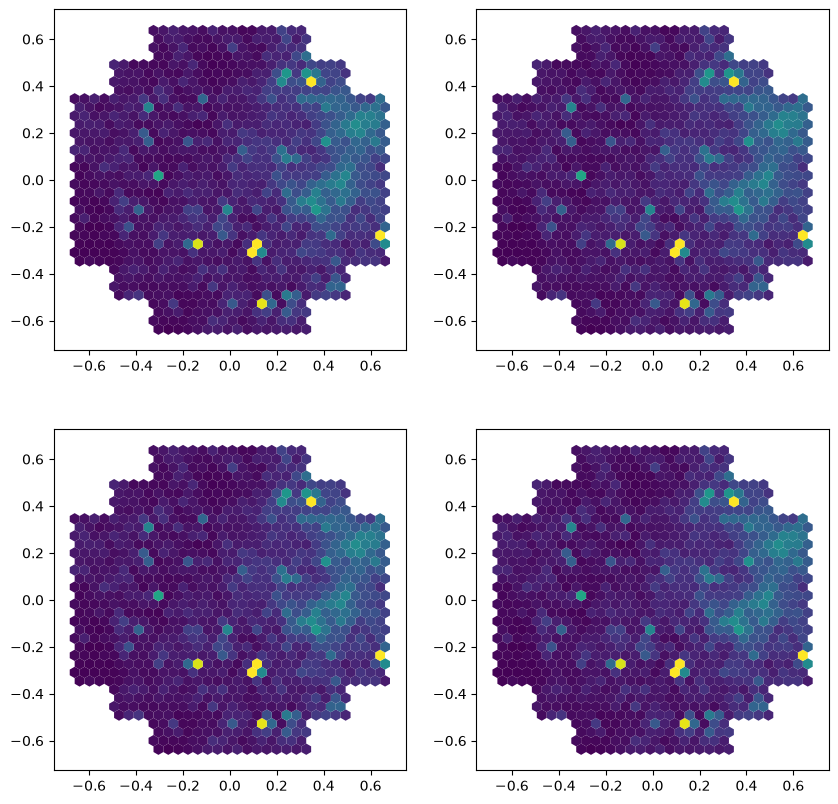

In [13]:
import matplotlib.pyplot as plt
from iactrace import Camera, show_image

camera = Camera.from_yaml("../../../iactrace/configs/HESS/HESS1U.yaml")

id = 0
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
ax1 = show_image(rates["CT1"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 0], vmax=500)
ax1 = show_image(rates["CT2"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 1], vmax=500)
ax1 = show_image(rates["CT3"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 0], vmax=500)
ax1 = show_image(rates["CT4"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 1], vmax=500)